# Escalado y Transformación de Datos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/04_escalado_y_transformacion.ipynb)



## Objetivos
- Comprender por qué las diferencias de escala entre variables pueden afectar el desempeño de muchos algoritmos de Machine Learning.
- Entender el funcionamiento matemático de los métodos de escalado más comunes: MinMaxScaler, StandardScaler y RobustScaler.
- Visualizar cómo el escalado modifica la distribución y magnitud de los datos.
- Identificar cuándo utilizar cada tipo de escalador según la distribución de los datos y la presencia de outliers.
- Aplicar correctamente el escalado en un flujo de trabajo de Machine Learning evitando data leakage.

## Prerrequisitos
- [Análisis de Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb)
- Conocimiento básico del flujo de trabajo en Machine Learning (datos de entrenamiento y prueba) [Conceptos Básicos de Machine Learning](../01_introduccion/01_conceptos_basicos.ipynb).
- Manipulación básica de datos con Pandas (`DataFrame`, selección de columnas).
- Conceptos básicos de estadística descriptiva: media, mediana, desviación estándar.
- Visualización básica de datos con `Matplotlib` o `Seaborn` (histogramas y *scatter plots*).


---
## Configuración del Entorno

In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


## 1. El Problema de las Escalas Dispares



Supongamos que queremos predecir el precio de una casa. Las variables son:
- Cantidad de habitaciones: Rango de `1` a `5`.
- Tamaño del terreno: Rango de `100` a `10000` metros cuadrados.

Muchos algoritmos de Machine Learning (como KNN, que mide distancias geométricas, o Regresión Lineal/Logística, que usa Descenso de Gradiente) son muy sensibles a la magnitud de los números. Si no escalamos los datos, el algoritmo pensará que una diferencia de 10 metros cuadrados es muchísimo más importante que una diferencia de 2 habitaciones (porque matemáticamente 10 > 2), lo cual es falso en la realidad inmobiliaria.

**El objetivo del escalado es poner a todas las características (*features*) en igualdad de condiciones matemáticas, sin destruir las relaciones de distancia proporcionales entre los puntos.**



## 2. Tipos de Escaladores en Scikit-Learn



Vamos a explorar los tres escaladores más comunes, generando un dataset sintético para visualizar exactamente qué hacen matemáticamente:



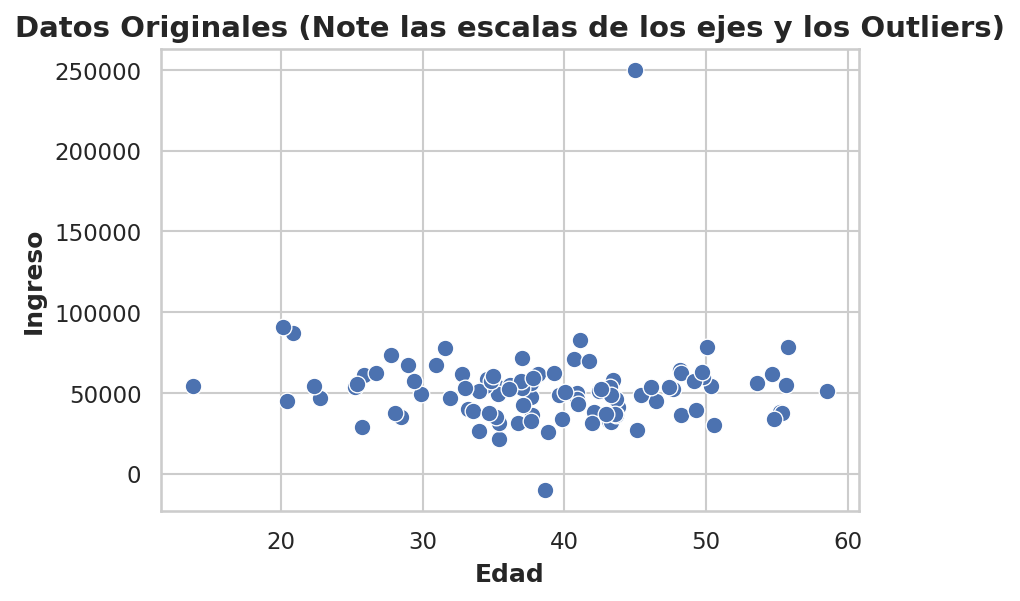

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Generar un dataset de "ingresos" (con un outlier muy grande) y "edad"
np.random.seed(42)
edad = np.random.normal(40, 10, 100) # Media 40, Desviación 10
ingreso = np.random.normal(50000, 15000, 100)

# Introducimos un par de outliers extremos en el ingreso
ingreso[0] = 250000
ingreso[1] = -10000 # Error de carga de datos hipotético

df = pd.DataFrame({'Edad': edad, 'Ingreso': ingreso})

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x='Edad', y='Ingreso', data=df)
plt.title("Datos Originales (Note las escalas de los ejes y los Outliers)")
plt.show()


### A) Normalización: MinMaxScaler



La normalización comprime (o expande) los datos para que encajen exactamente en un rango definido, usualmente `[0, 1]`.
La fórmula es:

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**¿Cuándo usarlo?**
- Cuando se necesita que todas las características estén estrictamente acotadas (ej. para algoritmos de Visión Computacional donde los píxeles van de 0 a 255).
- Cuando la distribución de los datos **no** es Gaussiana (no tiene forma de campana).

**La Debilidad:** Es extremadamente sensible a *outliers*. Como usa el `Max` y el `Min`, un solo valor atípico arruinará la escala para todos los demás datos.



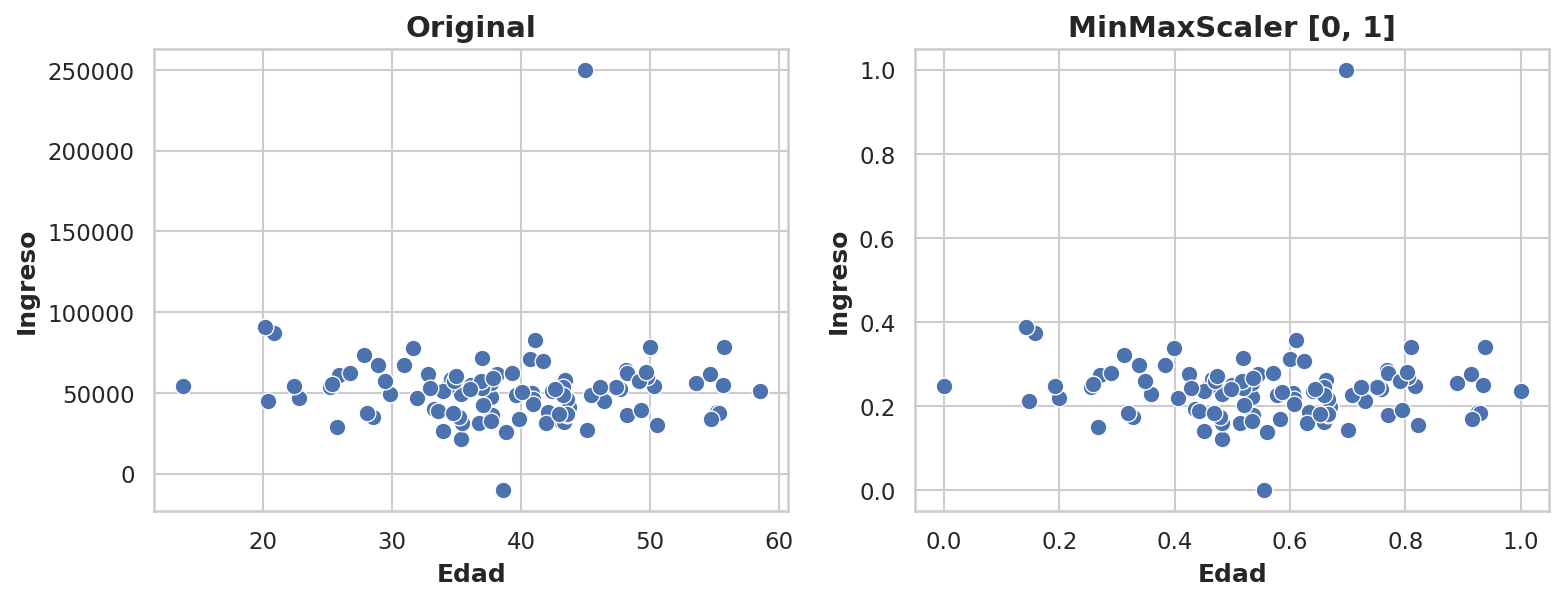

In [3]:
# Aplicar MinMaxScaler
minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x='Edad', y='Ingreso', data=df, ax=ax1).set_title('Original')
sns.scatterplot(x='Edad', y='Ingreso', data=df_minmax, ax=ax2).set_title('MinMaxScaler [0, 1]')
plt.show()



Observar la gráfica de `MinMaxScaler`. Toda la masa de datos "normales" de ingreso quedó comprimida en una línea estrecha cerca del `0.2`, porque el algoritmo se vio forzado a estirar el eje Y hasta el `1.0` solo para acomodar al outlier de 250,000. **El MinMaxScaler no maneja bien los outliers.**



### B) Estandarización: StandardScaler (Z-Score)



La estandarización re-centra los datos para que tengan una media ($\mu$) de 0 y una desviación estándar ($\sigma$) de 1.
La fórmula es:

$$Z = \frac{X - \mu}{\sigma}$$

**¿Cuándo usarlo?**
- Es el estándar por defecto (*pun intended*) en la mayoría de modelos (Regresión Logística, SVM, Redes Neuronales).
- Asume empíricamente que los datos tienen una distribución normal (Gaussiana).



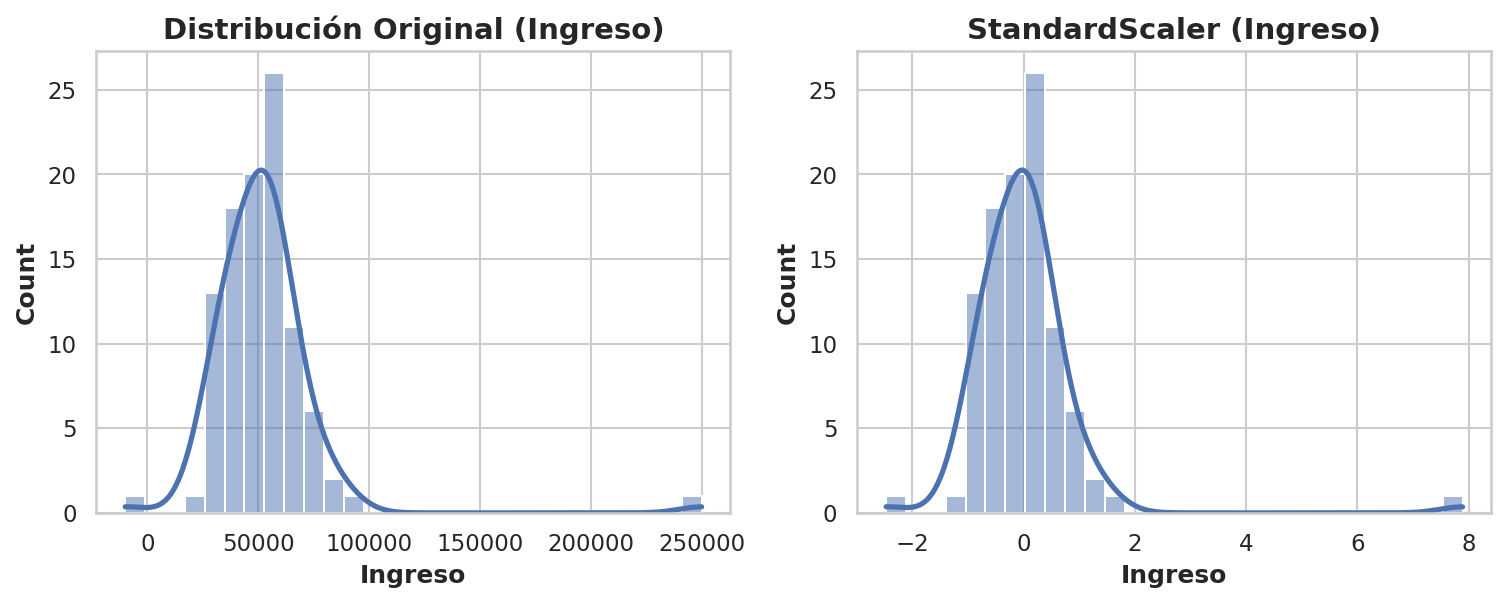

Media del Ingreso Estandarizado: -0.0000
Desviación Estándar del Ingreso Estandarizado: 1.0050


In [4]:
std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Ingreso'], kde=True, ax=ax1).set_title('Distribución Original (Ingreso)')
sns.histplot(df_std['Ingreso'], kde=True, ax=ax2).set_title('StandardScaler (Ingreso)')
plt.show()

print(f"Media del Ingreso Estandarizado: {df_std['Ingreso'].mean():.4f}")
print(f"Desviación Estándar del Ingreso Estandarizado: {df_std['Ingreso'].std():.4f}")



La forma de la distribución es idéntica, pero el eje X ahora mide "a cuántas desviaciones estándar estoy de la media". El outlier de 250k ahora tiene un valor Z de `~7`, lo que estadísticamente nos grita: *"Soy una anomalía"*.



### C) RobustScaler: El Salvador contra Outliers



Si recordamos el EDA inicial, la media es muy sensible a *outliers*. Por lo tanto, el `StandardScaler` (que usa la media) se ve ligeramente sesgado si hay anomalías masivas.

El `RobustScaler` utiliza estadísticos robustos: usa la **Mediana** en lugar de la media, y el **Rango Intercuartílico (IQR)** en lugar de la desviación estándar.

$$X_{robust} = \frac{X - Mediana}{Q_3 - Q_1}$$



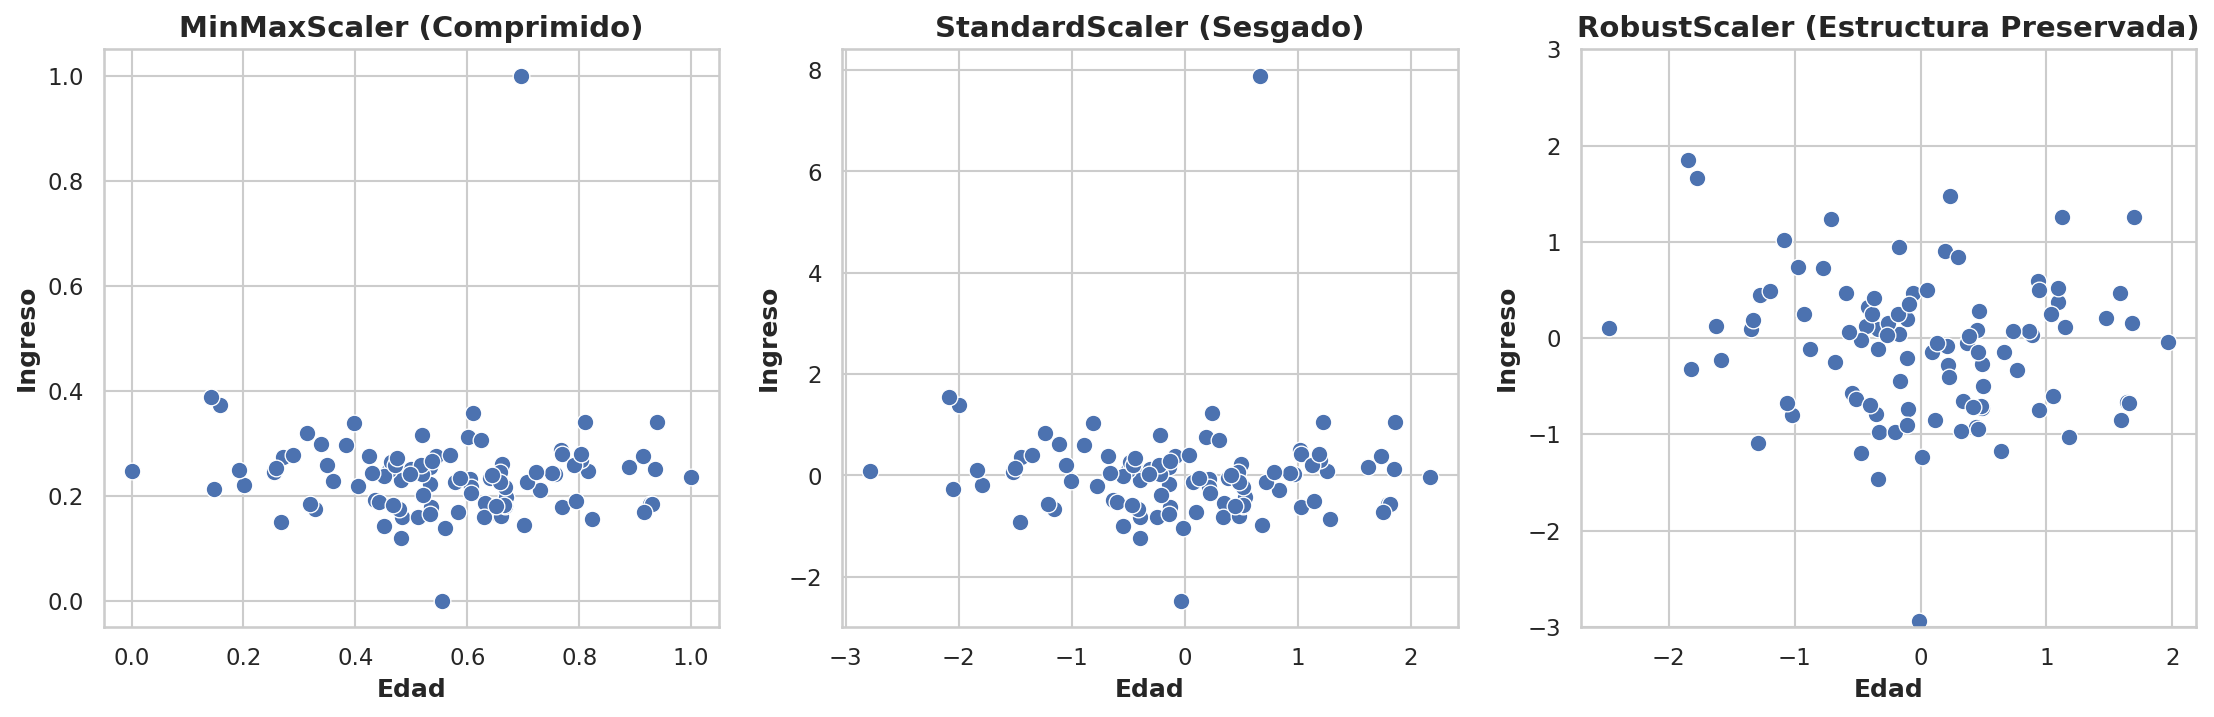

In [5]:
robust = RobustScaler()
df_robust = pd.DataFrame(robust.fit_transform(df), columns=df.columns)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='Edad', y='Ingreso', data=df_minmax, ax=ax1).set_title('MinMaxScaler (Comprimido)')
sns.scatterplot(x='Edad', y='Ingreso', data=df_std, ax=ax2).set_title('StandardScaler (Sesgado)')
sns.scatterplot(x='Edad', y='Ingreso', data=df_robust, ax=ax3).set_title('RobustScaler (Estructura Preservada)')

# Límites fijados, para visualizar mejor cómo queda la "masa" central de datos
ax3.set_ylim(-3, 3)
plt.show()



Observe que el `RobustScaler` ignora al outlier para calcular la escala, centrando la masa principal de datos perfectamente alrededor del `0`. (Hemos cortado el eje Y en la gráfica para evidenciarlo; el outlier sigue existiendo allá arriba, pero ya no arruina la escala del resto).



## 3. Resumen y Mejores Prácticas



1. **Escalar SIEMPRE** si se usa KNN, SVM, PCA, K-Means o Redes Neuronales.
2. **Los Árboles no lo necesitan:** Random Forest y XGBoost basan sus cortes en reglas lógicas (`Si X > 10`), por lo que son completamente inmunes a las escalas dispares.
3. **Flujo de Trabajo:**
   - Si no hay outliers extremos -> `StandardScaler`.
   - Si los límites deben ser estrictos -> `MinMaxScaler`.
   - Si hay outliers y se quiere mantener la distribución de la "masa" -> `RobustScaler`.
4. **Cuidado con la Fuga de Datos (*Data Leakage*):** Al igual que con las imputaciones, el escalador debe hacer `.fit()` **SOLO** en los datos de entrenamiento para aprender la media/min/max. Luego, se usa `.transform()` en los datos de validación/prueba. Hacer un `fit` en todo el dataset contamina el modelo con información del futuro. *Lo vemos bien más adelante...*



## Referencias


1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
2. [*Preprocessing data* en `scikit-learn`](https://scikit-learn.org/stable/modules/preprocessing.html)

## Entorno de Ejecución


In [6]:
from utils.environment import environment_table
environment_table(include_all=False)


Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
